# Notebook 03 — Feature Engineering
**Physics-informed, multi-scale time-series features**

We build features that encode the physical degradation mechanisms of centrifugal pumps:
- Slow drift from healthy baseline (baseline deviation features)
- Accelerating deterioration near failure (trend/slope features)
- Increasing noise as mechanical looseness grows (rolling std, CV features)

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from scipy.stats import spearmanr

from src.config import TRAIN_PATH, UNITS_PATH, TOP_N_FEATURES
from src.data_loader import load_and_validate_data, detect_sensor_columns
from src.label_engineer import RULLabelEngineer
from src.feature_engineer import PumpFeatureEngineer, select_features_by_importance
from src.eda_utils import select_rul_max_empirically
print("Imports OK")


Imports OK


In [2]:
train_df, units_df = load_and_validate_data(TRAIN_PATH, UNITS_PATH)
sensor_cols, _ = detect_sensor_columns(train_df)
rul_max = select_rul_max_empirically(train_df, units_df, sensor_cols, plot=False)

le = RULLabelEngineer(rul_max=rul_max)
df_labeled = le.fit_transform(train_df, units_df)
print("Data and labels ready.")


23:36:19 [data_loader] INFO: Loading training data…


23:36:19 [data_loader] INFO: =======================================================


23:36:19 [data_loader] INFO:   Units total    : 80


23:36:19 [data_loader] INFO:   Failed         : 72  |  Censored: 8


23:36:19 [data_loader] INFO:   Total rows     : 16,603


...

23:36:25 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 13,265


23:36:25 [eda_utils] INFO: Empirically selected RUL_MAX = 185 (mean |Spearman| = 0.3077)


23:36:25 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=185 | failed=72 | censored=8 | p90_lifetime=284


23:36:26 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 12,585


Data and labels ready.


## 1. Feature Engineering Pipeline

In [3]:
fe = PumpFeatureEngineer(sensor_cols=sensor_cols)
fe.fit(df_labeled)
df_features = fe.transform(df_labeled)

# Drop high-NaN features
df_features, dropped = fe.drop_high_nan_features(df_features)

meta_cols = ['unit_id','cycle','rul','raw_rul','sample_weight','in_degradation_window']
feature_cols_all = [c for c in df_features.select_dtypes(include='number').columns if c not in meta_cols]

print(f"Input columns      : {len(sensor_cols)} sensors")
print(f"Candidate features : {len(feature_cols_all)}")
print(f"Dropped (high NaN) : {len(dropped)}")
print(f"Net features       : {len(feature_cols_all)}")
print("\nFeature name samples:")
print("  Rolling:", [c for c in feature_cols_all if '_r5_' in c][:3])
print("  Trend  :", [c for c in feature_cols_all if '_slope' in c][:3])
print("  EWMA   :", [c for c in feature_cols_all if '_ewma' in c][:3])
print("  Baseline:", [c for c in feature_cols_all if '_zscore' in c][:3])

23:36:26 [feature_engineer] INFO: PumpFeatureEngineer fitted | 80 units | ~590 candidate features


23:37:37 [feature_engineer] INFO: Dropping 36 high-NaN features (>30%)


Input columns      : 15 sensors
Candidate features : 555
Dropped (high NaN) : 36
Net features       : 555

Feature name samples:
  Rolling: ['ambient_temp_c_r5_mean', 'ambient_temp_c_r5_std', 'ambient_temp_c_r5_min']
  Trend  : ['ambient_temp_c_slope10', 'ambient_temp_c_slope20', 'ambient_temp_c_slope30']
  EWMA   : ['ambient_temp_c_ewma01', 'ambient_temp_c_ewmadev01', 'ambient_temp_c_ewma03']
  Baseline: ['ambient_temp_c_zscore', 'vibration_rms_mms_zscore', 'bearing_temp_c_zscore']


## 2. Feature–RUL Correlation Analysis

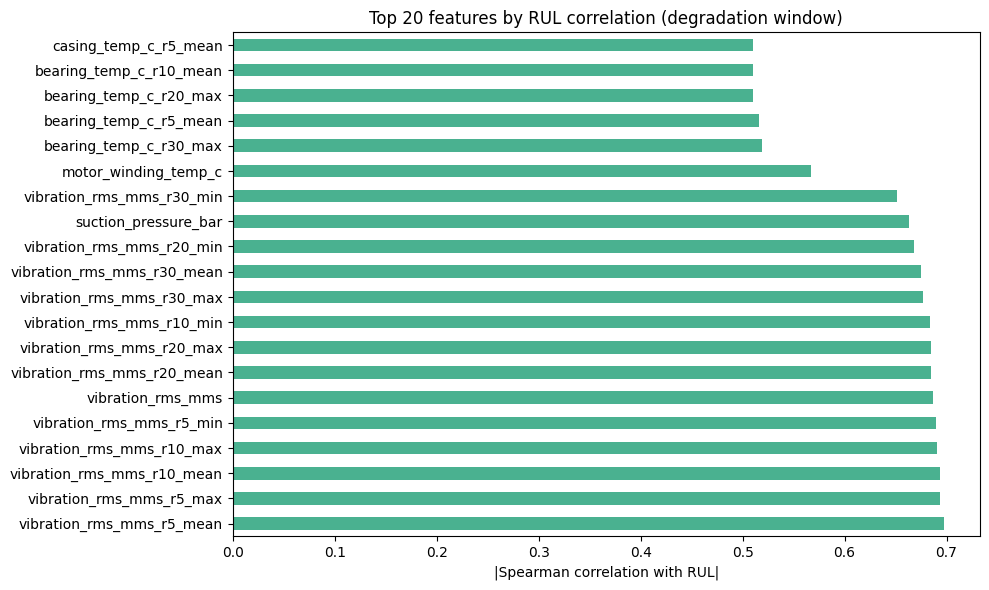

In [4]:
dw = df_features[df_features['in_degradation_window'] & df_features['rul'].notna()]
y = dw['rul'].values

corrs = {}
for col in feature_cols_all[:100]:  # Sample first 100 for speed
    x = dw[col].fillna(dw[col].median()).values
    c, _ = spearmanr(x, y)
    if not np.isnan(c): corrs[col] = abs(c)

top_corrs = pd.Series(corrs).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_corrs.plot.barh(ax=ax, color='#1D9E75', alpha=0.8)
ax.set_xlabel('|Spearman correlation with RUL|')
ax.set_title('Top 20 features by RUL correlation (degradation window)')
plt.tight_layout(); plt.show()


## 3. Feature Selection (XGBoost Importance)

In [5]:
y_sel = df_features['rul'].values
w_sel = df_features['sample_weight'].values

feature_cols = select_features_by_importance(
    df_features[feature_cols_all], y_sel, w_sel,
    top_n=TOP_N_FEATURES
)
print(f"Selected {len(feature_cols)} features")
print("\nTop 10 selected:")
for fc in feature_cols[:10]:
    print(f"  {fc}")


23:37:49 [feature_engineer] INFO: Feature selection: 555 → 150 features | top gain: 0.20120 | bottom kept: 0.00096


Selected 150 features

Top 10 selected:
  oil_particle_count_ewma03
  oil_particle_count_ewma05
  vibration_rms_mms_r30_max
  discharge_pressure_bar_ewma03
  vibration_rms_mms_r30_mean
  motor_winding_temp_c_ewma05
  oil_particle_count_ewma01
  feat_specific_vib
  discharge_pressure_bar_r10_mean
  discharge_pressure_bar_r30_cv


## 4. Visualise Feature Behaviour Near Failure

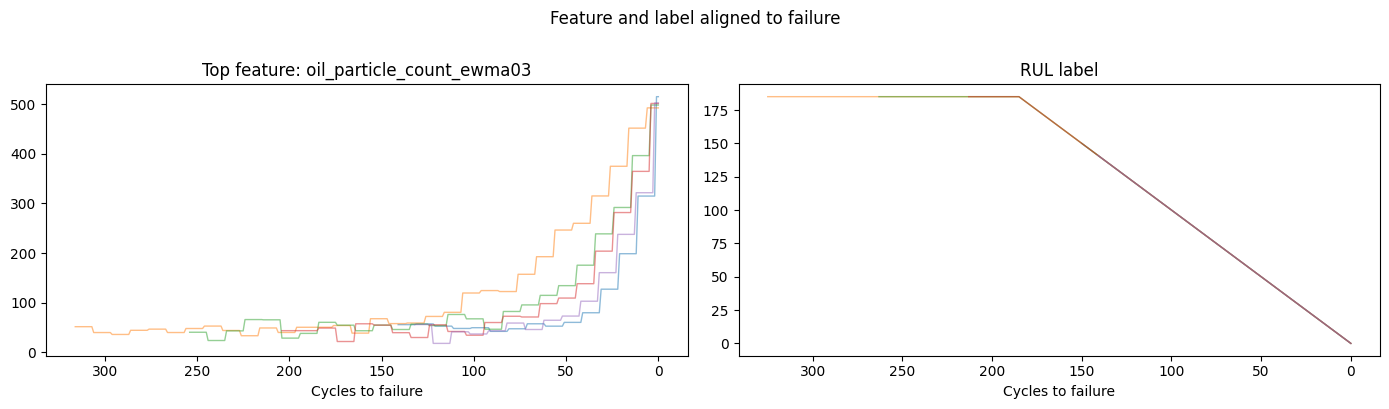

In [6]:
# For the top feature, plot rolling window behaviour aligned to failure
top_feat = feature_cols[0]
failed_ids = list(le.failed_ids_)[:5]
max_cycles = {uid: train_df[train_df['unit_id']==uid]['cycle'].max()
              for uid in failed_ids}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for uid in failed_ids:
    unit = df_features[df_features['unit_id']==uid].sort_values('cycle')
    rul_axis = max_cycles[uid] - unit['cycle'].values
    if top_feat in unit.columns:
        axes[0].plot(rul_axis, unit[top_feat].values, alpha=0.5, lw=1)
    axes[1].plot(rul_axis, unit['rul'].values, alpha=0.5, lw=1)

for ax, title in zip(axes, [f'Top feature: {top_feat}', 'RUL label']):
    ax.invert_xaxis()
    ax.set_xlabel('Cycles to failure')
    ax.set_title(title)

plt.suptitle('Feature and label aligned to failure', y=1.01)
plt.tight_layout(); plt.show()


## 5. Baseline Deviation Feature Deep-Dive

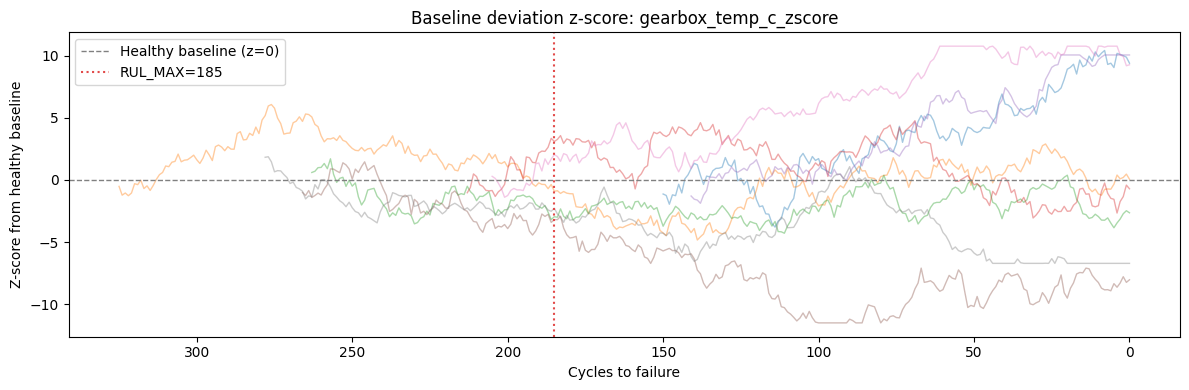

In [7]:
# Show how z-score feature captures the healthy→degraded transition
zscore_cols = [c for c in feature_cols if '_zscore' in c]
if zscore_cols:
    col = zscore_cols[0]
    uid_sample = list(le.failed_ids_)[:8]
    fig, ax = plt.subplots(figsize=(12, 4))
    for uid in uid_sample:
        unit = df_features[df_features['unit_id']==uid].sort_values('cycle')
        max_c = max_cycles.get(uid, unit['cycle'].max())
        rul_axis = max_c - unit['cycle'].values
        ax.plot(rul_axis, unit[col].values, alpha=0.4, lw=1)
    ax.axhline(0, ls='--', color='gray', lw=1, label='Healthy baseline (z=0)')
    ax.axvline(rul_max, ls=':', color='#E24B4A', lw=1.5, label=f'RUL_MAX={rul_max}')
    ax.invert_xaxis()
    ax.set_xlabel('Cycles to failure'); ax.set_ylabel('Z-score from healthy baseline')
    ax.set_title(f'Baseline deviation z-score: {col}')
    ax.legend(); plt.tight_layout(); plt.show()


## Summary

| Feature Category | Count | Key Insight |
|---|---|---|
| Raw sensor values | n_sensors | Current reading |
| Rolling stats (4 windows × 6 stats) | n×24 | Local level and volatility |
| Trend (3 windows × 2) | n×6 | Drift rate and acceleration |
| EWMA (3 alphas × 2) | n×6 | Noise-robust level + deviation |
| Baseline deviation | n×2 | Z-score vs own healthy baseline |
| Cross-sensor interactions | ~4 | Physics-driven efficiency/ratio |